Episode 200, Reward: 674.00, Success: False, Epsilon: 0.367
Episode 400, Reward: 904.00, Success: False, Epsilon: 0.135
Episode 600, Reward: 1333.00, Success: True, Epsilon: 0.050
Episode 800, Reward: 1363.00, Success: True, Epsilon: 0.050
Episode 1000, Reward: 1323.00, Success: True, Epsilon: 0.050
Episode 1200, Reward: 1343.00, Success: True, Epsilon: 0.050
Episode 1400, Reward: 1343.00, Success: True, Epsilon: 0.050
Episode 1600, Reward: 1333.00, Success: True, Epsilon: 0.050
Episode 1800, Reward: 1313.00, Success: True, Epsilon: 0.050
Episode 2000, Reward: 1338.00, Success: True, Epsilon: 0.050
Episode 2200, Reward: 1353.00, Success: True, Epsilon: 0.050
Episode 2400, Reward: 1368.00, Success: True, Epsilon: 0.050
Episode 2600, Reward: 1343.00, Success: True, Epsilon: 0.050
Episode 2800, Reward: 590.00, Success: False, Epsilon: 0.050
Episode 3000, Reward: 1353.00, Success: True, Epsilon: 0.050

Final Result
Start: (654, 114)
Goal: (25, 759)
Extracted path length: 1285
Reached goal:

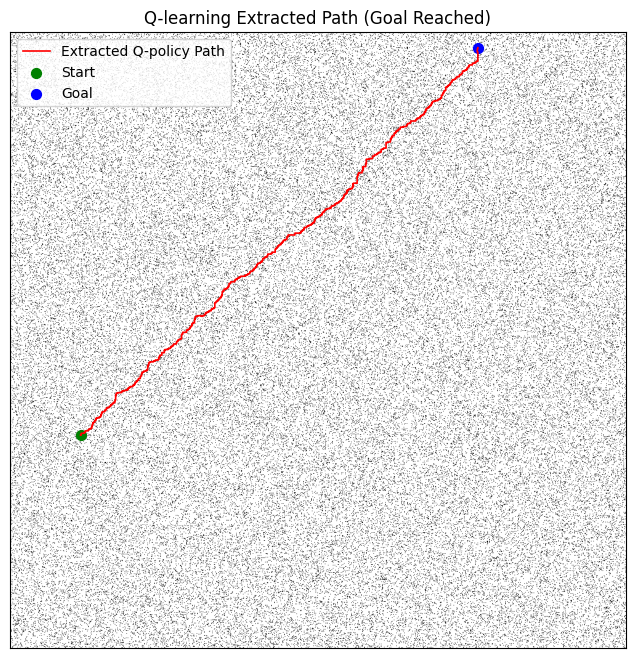

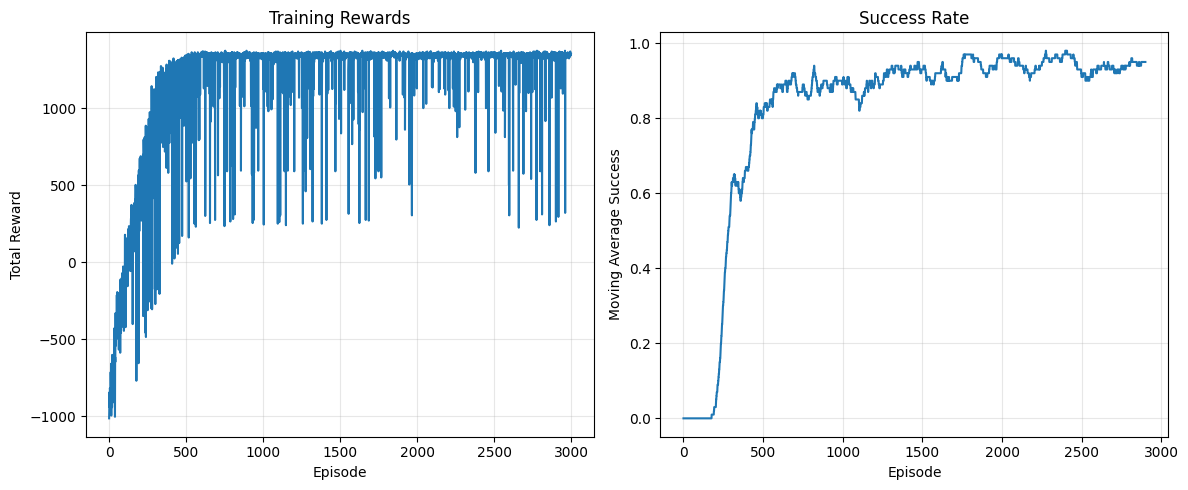

Saved: a2q4_qlearning_path.png
Saved: a2q4_qlearning_training.png


In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict

GRID_SIZE = 1000
OBSTACLE_RATIO = 0.10

EPISODES = 3000
MAX_STEPS = 2000

ALPHA = 0.1
GAMMA = 0.99

EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 0.995

SEED = 42

ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
ACTION_NAMES = ["UP", "DOWN", "LEFT", "RIGHT"]

np.random.seed(SEED)
random.seed(SEED)


def generate_grid():
    grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.uint8)

    total = GRID_SIZE * GRID_SIZE
    obstacles = int(total * OBSTACLE_RATIO)

    idx = np.random.choice(total, obstacles, replace=False)
    grid.flat[idx] = 1

    return grid


def random_free(grid):
    while True:
        r = random.randint(0, GRID_SIZE - 1)
        c = random.randint(0, GRID_SIZE - 1)

        if grid[r, c] == 0:
            return (r, c)


def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def step(state, action, grid):
    r, c = state
    dr, dc = ACTIONS[action]

    nr = int(np.clip(r + dr, 0, GRID_SIZE - 1))
    nc = int(np.clip(c + dc, 0, GRID_SIZE - 1))

    # obstacle hit: stay in same state
    if grid[nr, nc] == 1:
        return state, True

    return (nr, nc), False


class QAgent:
    def __init__(self):
        self.Q = defaultdict(lambda: np.zeros(4))

    def act(self, state, epsilon):
        if random.random() < epsilon:
            return random.randint(0, 3)

        q = self.Q[state]
        return int(np.random.choice(np.flatnonzero(q == q.max())))

    def update(self, s, a, r, sn, done):
        best_next = 0.0 if done else np.max(self.Q[sn])

        self.Q[s][a] += ALPHA * (
            r + GAMMA * best_next - self.Q[s][a]
        )



def train():
    grid = generate_grid()

    start = random_free(grid)
    goal = random_free(grid)

    while goal == start:
        goal = random_free(grid)

    agent = QAgent()

    epsilon = EPS_START
    rewards = []
    success_history = []

    for ep in range(EPISODES):
        state = start
        total_reward = 0.0
        success = False

        for step_id in range(MAX_STEPS):
            action = agent.act(state, epsilon)
            next_state, hit_obstacle = step(state, action, grid)

            if next_state == goal:
                reward = 100.0
                done = True
                success = True

            else:
                old_d = manhattan(state, goal)
                new_d = manhattan(next_state, goal)

                if hit_obstacle:
                    reward = -5.0
                elif new_d < old_d:
                    reward = 1.0
                elif new_d > old_d:
                    reward = -1.0
                else:
                    reward = -0.1

                done = False

            agent.update(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if done:
                break

        epsilon = max(EPS_END, epsilon * EPS_DECAY)

        rewards.append(total_reward)
        success_history.append(1 if success else 0)

        if (ep + 1) % 200 == 0:
            print(
                f"Episode {ep + 1}, "
                f"Reward: {total_reward:.2f}, "
                f"Success: {success}, "
                f"Epsilon: {epsilon:.3f}"
            )

    return agent, grid, start, goal, rewards, success_history

def extract_path(agent, start, goal, grid):
    state = start
    path = [state]
    visited = set()

    for _ in range(MAX_STEPS):
        if state == goal:
            break

        if state in visited:
            # loop detected
            break

        visited.add(state)

        q = agent.Q[state]
        action = int(np.argmax(q))

        next_state, _ = step(state, action, grid)

        path.append(next_state)
        state = next_state

    reached_goal = path[-1] == goal

    return path, reached_goal


def plot_path(grid, path, start, goal, reached_goal):
    plt.figure(figsize=(8, 8))

    plt.imshow(grid, cmap="gray_r", origin="upper")

    rows = [p[0] for p in path]
    cols = [p[1] for p in path]

    plt.plot(cols, rows, color="red", linewidth=1.2, label="Extracted Q-policy Path")
    plt.scatter(start[1], start[0], c="green", s=50, label="Start")
    plt.scatter(goal[1], goal[0], c="blue", s=50, label="Goal")

    title = "Q-learning Extracted Path"
    if reached_goal:
        title += " (Goal Reached)"
    else:
        title += " (Goal Not Reached / Loop Detected)"

    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend()

    plt.savefig("a2q4_qlearning_path.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_learning(rewards, success_history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(rewards)
    plt.title("Training Rewards")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    window = 100

    if len(success_history) >= window:
        success_ma = np.convolve(
            success_history,
            np.ones(window) / window,
            mode="valid"
        )
        plt.plot(success_ma)
    else:
        plt.plot(success_history)

    plt.title("Success Rate")
    plt.xlabel("Episode")
    plt.ylabel("Moving Average Success")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("a2q4_qlearning_training.png", dpi=150, bbox_inches="tight")
    plt.show()


agent, grid, start, goal, rewards, success_history = train()

path, reached_goal = extract_path(agent, start, goal, grid)

print("\nFinal Result")
print("=" * 50)
print("Start:", start)
print("Goal:", goal)
print("Extracted path length:", len(path))
print("Reached goal:", reached_goal)
print("Final success rate over last 100 episodes:", np.mean(success_history[-100:]))
print("Number of visited Q-states:", len(agent.Q))

plot_path(grid, path, start, goal, reached_goal)
plot_learning(rewards, success_history)

print("Saved: a2q4_qlearning_path.png")
print("Saved: a2q4_qlearning_training.png")

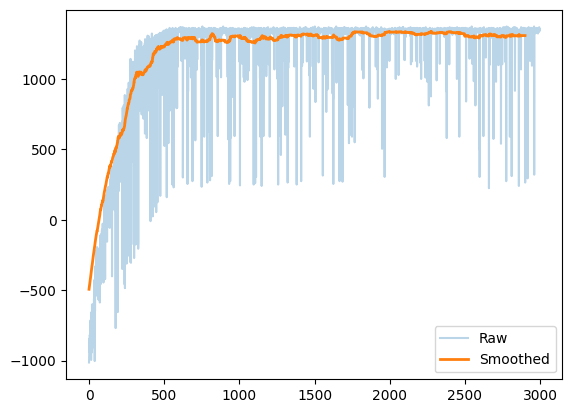

In [2]:
def smooth(x, window=100):
    return np.convolve(x, np.ones(window)/window, mode='valid')

def plot_smoothed_rewards(rewards):
    plt.figure(figsize=(8,5))

    smoothed = smooth(rewards, window=100)

    plt.plot(smoothed)
    plt.title("Smoothed Training Rewards (Moving Avg)")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.grid(True, alpha=0.3)

    plt.show()


plt.plot(rewards, alpha=0.3, label="Raw")
plt.plot(smooth(rewards, 100), label="Smoothed", linewidth=2)
plt.legend()